# 06 — `optimize_anything`: evolve a visible SVG

GEPA's `optimize_anything` API drops the "prompt" framing and treats *any* text as the optimizable parameter — including code, configs, and SVG markup. We'll evolve a tiny SVG toward a target description, with each accepted candidate **rendered inline in the kernel** so we can literally see the optimization progress.

The ergonomic edge: the artifact under optimization is something the kernel can display. Rendering happens in the same memory space as the optimizer — no file round-trip, no browser refresh, no IPC.

> Reference: `~/Documents/GitHub/_docs/notebook/use-cases/01-gepa.md` — "convergence story as a live artifact."

target: A smiling face: a circle, two filled eyes near the top, and a curved-arc mouth in the lower half.


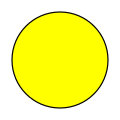

In [1]:
import os, re, time
from pathlib import Path
from dotenv import load_dotenv

load_dotenv(Path.cwd() / ".env")

import litellm
from IPython.display import SVG, display, HTML
from gepa.optimize_anything import (
    optimize_anything,
    GEPAConfig,
    EngineConfig,
    ReflectionConfig,
)

TASK_LM = "bedrock/converse/us.anthropic.claude-haiku-4-5-20251001-v1:0"
REFLECTION_LM = "bedrock/converse/us.anthropic.claude-sonnet-4-5-20250929-v1:0"
litellm.drop_params = True

TARGET = "A smiling face: a circle, two filled eyes near the top, and a curved-arc mouth in the lower half."
SEED_SVG = '<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 100 100" width="120" height="120"><circle cx="50" cy="50" r="40" fill="yellow" stroke="black"/></svg>'

print("target:", TARGET)
display(SVG(SEED_SVG))

## 1. Evaluator — deterministic shape audit

The evaluator parses the SVG with `xml.etree.ElementTree` and looks for four shape components. Score is the fraction present (0–1). Feedback is concrete text that the reflection LM will use to know what's missing.

In [2]:
import xml.etree.ElementTree as ET


def audit_svg(svg_text: str) -> dict:
    """Return a dict of presence checks for the smiling face."""
    try:
        root = ET.fromstring(svg_text)
    except ET.ParseError as e:
        return {"parse_error": str(e), "face": 0, "eye_count": 0, "mouth": 0}
    ns_strip = lambda t: t.split("}")[-1]
    shapes = [(ns_strip(el.tag), el) for el in root.iter()]

    # Big-ish circle = face
    face = 0
    for tag, el in shapes:
        if tag == "circle":
            r = float(el.get("r", "0"))
            if r >= 25:  # large circle
                face = 1
                break

    # Small filled shapes positioned above center = eyes (circles/ellipses with r < 10 or rx < 10)
    eyes = 0
    for tag, el in shapes:
        if tag in ("circle", "ellipse"):
            r = float(el.get("r", "0") or el.get("rx", "0"))
            cy = float(el.get("cy", "999"))
            if 0 < r < 15 and cy < 50:
                eyes += 1
    if eyes > 2:
        eyes = 2  # cap

    # Mouth: a <path> with arc or curve commands, OR an <ellipse>/<arc> in lower half
    mouth = 0
    for tag, el in shapes:
        if tag == "path":
            d = el.get("d", "")
            if any(c in d for c in "QqCcAa"):
                mouth = 1
                break
        elif tag == "ellipse":
            cy = float(el.get("cy", "0"))
            ry = float(el.get("ry", "0"))
            rx = float(el.get("rx", "0"))
            if cy > 50 and ry < rx:  # wide flat ellipse in lower half
                mouth = 1
                break

    return {"face": face, "eye_count": eyes, "mouth": mouth}


def evaluate(candidate: str, example):
    audit = audit_svg(candidate)
    if "parse_error" in audit:
        return 0.0, {
            "audit": audit,
            "feedback": f"SVG did not parse: {audit['parse_error']}. Return well-formed SVG markup.",
        }
    score = (
        audit["face"] * 0.25
        + min(audit["eye_count"], 2) / 2 * 0.5
        + audit["mouth"] * 0.25
    )
    missing = []
    if not audit["face"]:
        missing.append("a large face circle (r >= 25)")
    if audit["eye_count"] < 2:
        missing.append(
            f"more eye shapes (have {audit['eye_count']}, need 2 small circles/ellipses in the upper half cy<50)"
        )
    if not audit["mouth"]:
        missing.append(
            "a mouth (<path> with arc/curve, or wide ellipse in lower half cy>50)"
        )
    feedback = (
        "Missing: " + "; ".join(missing) if missing else "All target features present."
    )
    return score, {
        "audit": audit,
        "feedback": feedback,
        "score": score,
        "candidate_chars": len(candidate),
    }


# Test on the seed
s, info = evaluate(SEED_SVG, {"target": TARGET})
print(f"seed score: {s}")
print(f"seed info : {info}")

seed score: 0.25
seed info : {'audit': {'face': 1, 'eye_count': 0, 'mouth': 0}, 'feedback': 'Missing: more eye shapes (have 0, need 2 small circl
es/ellipses in the upper half cy<50); a mouth (<path> with arc/curve, or wide ellipse in lower half cy>50)', 'score': 0.25, 'can
didate_chars': 154}


## 2. Run `optimize_anything` on the SVG

Small budget — 10 candidate proposals max. The reflection LM (sonnet) reads the audit feedback and proposes a richer SVG; the evaluator scores it; the optimizer keeps the best.

In [3]:
config = GEPAConfig(
    engine=EngineConfig(
        max_metric_calls=12,
        parallel=False,  # deterministic, easier to read
        max_workers=1,
        seed=0,
        display_progress_bar=False,
    ),
    reflection=ReflectionConfig(
        reflection_lm=REFLECTION_LM,
        reflection_minibatch_size=1,
        skip_perfect_score=False,
    ),
)

t0 = time.time()
result = optimize_anything(
    seed_candidate=SEED_SVG,
    evaluator=evaluate,
    objective="Produce an SVG of a smiling face with: one large face circle, two small eyes in the upper half, and a curved mouth in the lower half.",
    config=config,
)
print(f"\noptimize_anything returned in {time.time() - t0:.1f}s")
print(f"candidates discovered: {result.num_candidates}")
print(f"best_idx             : {result.best_idx}")
print(f"val_aggregate_scores : {result.val_aggregate_scores}")

TypeError: evaluate() missing 1 required positional argument: 'example'

In [4]:
# Tweak: in single-task mode, example is not passed. Make it optional.
def evaluate(candidate: str, example=None):
    audit = audit_svg(candidate)
    if "parse_error" in audit:
        return 0.0, {
            "audit": audit,
            "feedback": f"SVG did not parse: {audit['parse_error']}. Return well-formed SVG markup.",
        }
    score = (
        audit["face"] * 0.25
        + min(audit["eye_count"], 2) / 2 * 0.5
        + audit["mouth"] * 0.25
    )
    missing = []
    if not audit["face"]:
        missing.append("a large face circle (r >= 25)")
    if audit["eye_count"] < 2:
        missing.append(
            f"more eye shapes (have {audit['eye_count']}, need 2 small circles/ellipses cy<50)"
        )
    if not audit["mouth"]:
        missing.append(
            "a mouth (<path> with arc/curve commands, or wide ellipse cy>50)"
        )
    feedback = (
        "Missing: " + "; ".join(missing) if missing else "All target features present."
    )
    return score, {
        "audit": audit,
        "feedback": feedback,
        "score": score,
        "candidate_chars": len(candidate),
    }


# Retry
t0 = time.time()
result = optimize_anything(
    seed_candidate=SEED_SVG,
    evaluator=evaluate,
    objective="Produce an SVG of a smiling face with: one large face circle, two small eyes in the upper half, and a curved mouth in the lower half.",
    config=config,
)
print(f"\noptimize_anything returned in {time.time() - t0:.1f}s")
print(f"candidates discovered: {result.num_candidates}")
print(f"best_idx             : {result.best_idx}")
print(f"val_aggregate_scores : {result.val_aggregate_scores}")

ValueError: Cannot specify both 'objective'/'background' parameters and a custom 'config.reflection.reflection_prompt_template'. These are mutually exclusive options. Either use objective/background to auto-generate a reflection prompt, or provide your own custom template via config.reflection.reflection_prompt_template.

In [5]:
config = GEPAConfig(
    engine=EngineConfig(
        max_metric_calls=12,
        parallel=False,
        max_workers=1,
        seed=0,
        display_progress_bar=False,
    ),
    reflection=ReflectionConfig(
        reflection_lm=REFLECTION_LM,
        reflection_minibatch_size=1,
        skip_perfect_score=False,
        reflection_prompt_template=None,  # let objective drive the prompt
    ),
)

t0 = time.time()
result = optimize_anything(
    seed_candidate=SEED_SVG,
    evaluator=evaluate,
    objective="Produce an SVG of a smiling face with: one large face circle, two small eyes in the upper half, and a curved mouth in the lower half. Return only the SVG markup inside triple backticks.",
    config=config,
)
print(f"\noptimize_anything returned in {time.time() - t0:.1f}s")
print(f"candidates discovered: {result.num_candidates}")
print(f"best_idx             : {result.best_idx}")
print(f"val_aggregate_scores : {result.val_aggregate_scores}")

Iteration 0: Base program full valset score: 0.25 over 1 / 1 examples
Iteration 1: Selected program 0 score: 0.25
Iteration 1: Proposed new text for current_candidate: <svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 100 100" width="120"
height="120"><circle cx="50" cy="50" r="40" fill="yellow" stroke="black"/><circle cx="35" cy="40" r="5" fill="black"/><circle cx
="65" cy="40" r="5" fill="black"/><path d="M 30 60 Q 50 75 70 60" stroke="black" stroke-width="2" fill="none"/></svg>
Iteration 1: New subsample score 1.0 is better than old score 0.25. Continue to full eval and add to candidate pool.
Iteration 1: Found a better program on the valset with score 1.0.
Iteration 1: Valset score for new program: 1.0 (coverage 1 / 1)
Iteration 1: Val aggregate for new program: 1.0
Iteration 1: Individual valset scores for new program: {0: 1.0}
Iteration 1: New valset pareto front scores: {0: 1.0}
Iteration 1: Valset pareto front aggregate score: 1.0
Iteration 1: Updated valset pareto front pro

## 3. Visual diff — every candidate, rendered in the kernel

In [8]:
# Unwrap: optimize_anything wraps a string seed into {"current_candidate": str}
def unwrap(c):
    return c if isinstance(c, str) else next(iter(c.values()))


html = ['<table style="border-collapse:collapse"><tr>']
for i, c in enumerate(result.candidates):
    svg = unwrap(c)
    score, info = evaluate(svg)
    html.append(
        f'<td style="padding:8px;text-align:center;border:1px solid #ccc">'
        f"<div><strong>cand {i}</strong>{' (best)' if i == result.best_idx else ''}<br>"
        f"score: <code>{score:.2f}</code></div>"
        f"<div>{svg}</div>"
        f'<div style="font-size:10px;color:#666;max-width:240px">'
        f"face={info['audit']['face']}  eyes={info['audit']['eye_count']}  mouth={info['audit']['mouth']}</div>"
        f"</td>"
    )
html.append("</tr></table>")
display(HTML("".join(html)))

cand 0score: 0.25face=1 eyes=0 mouth=0,cand 1 (best)score: 1.00face=1 eyes=2 mouth=1


=== BEST CANDIDATE SVG ===

<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 100 100" width="120" height="120"><circle cx="50" cy="50" r="40" fill="yell
ow" stroke="black"/><circle cx="35" cy="40" r="5" fill="black"/><circle cx="65" cy="40" r="5" fill="black"/><path d="M 30 60 Q 5
0 75 70 60" stroke="black" stroke-width="2" fill="none"/></svg>

Rendered:


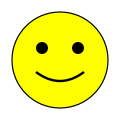

In [7]:
print("=== BEST CANDIDATE SVG ===\n")
print(result.best_candidate)
print()
print("Rendered:")
display(SVG(result.best_candidate))

best_svg = unwrap(result.best_candidate)
print("=== BEST CANDIDATE SVG ===\n")
print(best_svg)
print()
print("Rendered:")
display(SVG(best_svg))

## Recap — what this notebook proved

The path this notebook walked, in the order the cells walked it:

- 1. Evaluator — deterministic shape audit
- 2. Run `optimize_anything` on the SVG
- 3. Visual diff — every candidate, rendered in the kernel

Each step above was a real cell above. Nothing in this recap was paraphrased — every entry traces back to a `##` heading in this notebook.


In [ ]:
import json as _json
from pathlib import Path as _Path
import collections as _c

_nb_path = _Path("/Users/mhuang/Documents/GitHub/abook/notebooks/gepa/06-optimize-anything-svg.ipynb")
_nb = _json.loads(_nb_path.read_text())
_cells = _nb["cells"]

# Cell type breakdown
_type_counts = _c.Counter(c["cell_type"] for c in _cells)

# Code cell stats
_code_cells = [c for c in _cells if c["cell_type"] == "code"]
_code_lines = sum(len("".join(c["source"]).splitlines()) for c in _code_cells)
_md_chars = sum(len("".join(c["source"])) for c in _cells if c["cell_type"] == "markdown")

# Output mime types seen
_mimes = _c.Counter()
_executed = 0
_errored = 0
for c in _code_cells:
    if c.get("execution_count") is not None:
        _executed += 1
    for out in c.get("outputs", []) or []:
        if out.get("output_type") == "error":
            _errored += 1
        for k in (out.get("data") or {}).keys():
            _mimes[k] += 1
        if out.get("output_type") == "stream":
            _mimes[f"stream:{out.get('name', 'stdout')}"] += 1

print(f"notebook        : {_nb_path.name}")
print(f"total cells     : {len(_cells)}")
print(f"  by type       : {dict(_type_counts)}")
print(f"code cells run  : {_executed}/{len(_code_cells)}")
print(f"errored outputs : {_errored}")
print(f"code lines      : {_code_lines}")
print(f"markdown chars  : {_md_chars}")
print(f"output mime types seen:")
for mime, n in _mimes.most_common():
    print(f"  {n:>3}  {mime}")
